In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor

### Train/Validation/Test Split: Proper data splitting
Training set (≈60–70%)
Used to fit the model.

Validation set (≈15–20%)
Used to tune hyperparameters (e.g., Ridge α, tree depth).
Prevents “peeking” at the test set.

Test set (≈15–20%)
Used once at the end to measure final model performance.
Acts as new, unseen data.

So the usual split is Train → Validation → Test.

In [2]:
# If you dont want to use train/Validation/Test, you can also use cross validation with different folds

# Small/medium dataset → use k-fold CV.

# Large dataset → simple train/validation/test split is enough.

### Cross-Validation: K-fold, stratified, time series

In [3]:
df = pd.read_csv("car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


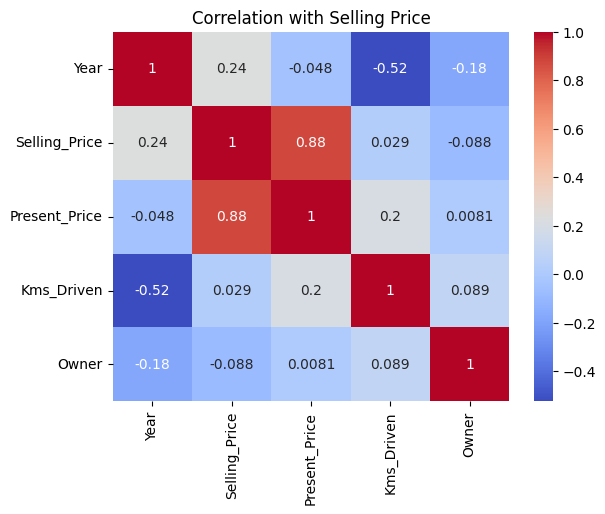

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation with Selling Price")
plt.show()

In [6]:
cat_cols = ['Fuel_Type', 'Seller_Type', 'Transmission']

df = pd.get_dummies(df, columns=cat_cols, dtype=int)
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual
0,ritz,2014,3.35,5.59,27000,0,0,0,1,1,0,0,1
1,sx4,2013,4.75,9.54,43000,0,0,1,0,1,0,0,1
2,ciaz,2017,7.25,9.85,6900,0,0,0,1,1,0,0,1
3,wagon r,2011,2.85,4.15,5200,0,0,0,1,1,0,0,1
4,swift,2014,4.60,6.87,42450,0,0,1,0,1,0,0,1


In [7]:
from sklearn.preprocessing import LabelEncoder

ohe = LabelEncoder()
df['name_encoded'] = ohe.fit_transform(df['Car_Name'])

In [8]:
df = df.drop("Car_Name", axis=1)
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual,name_encoded
0,2014,3.35,5.59,27000,0,0,0,1,1,0,0,1,90
1,2013,4.75,9.54,43000,0,0,1,0,1,0,0,1,93
2,2017,7.25,9.85,6900,0,0,0,1,1,0,0,1,68
3,2011,2.85,4.15,5200,0,0,0,1,1,0,0,1,96
4,2014,4.60,6.87,42450,0,0,1,0,1,0,0,1,92


In [9]:
from datetime import datetime

current_year = datetime.now().year

df["age"] = current_year - df["Year"]

In [10]:
df = df.drop("Year", axis=1)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Owner,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Dealer,Seller_Type_Individual,Transmission_Automatic,Transmission_Manual,name_encoded,age
0,3.35,5.59,27000,0,0,0,1,1,0,0,1,90,11
1,4.75,9.54,43000,0,0,1,0,1,0,0,1,93,12
2,7.25,9.85,6900,0,0,0,1,1,0,0,1,68,8
3,2.85,4.15,5200,0,0,0,1,1,0,0,1,96,14
4,4.60,6.87,42450,0,0,1,0,1,0,0,1,92,11


In [11]:
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)

In [12]:
from sklearn.linear_model import LinearRegression

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train) 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
y_train_pred = linear_reg.predict(X_train)
y_test_pred = linear_reg.predict(X_test)

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train performance
print("Train R²:", r2_score(y_train, y_train_pred))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("Train MAE:", mean_absolute_error(y_train, y_train_pred))

# Test performance
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

Train R²: 0.8854345315599734
Train RMSE: 1.6399804390233768
Train MAE: 1.1454280346112695
Test R²: 0.8633977464821948
Test RMSE: 2.089639157511071
Test MAE: 1.1999376119487544


In [15]:
kf = KFold(n_splits = 5, shuffle = True, random_state = 42)

scoring = ['neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2']
scoring_result = cross_validate(linear_reg, X, y, cv=kf, return_train_score = True, scoring = scoring)

MAE_mean = (-scoring_result['test_neg_mean_absolute_error'])
MSE_mean = (-scoring_result['test_neg_mean_squared_error'])
RMSE_mean = (-scoring_result['test_neg_root_mean_squared_error'])
R2_Score_mean = scoring_result['test_r2']

print(MAE_mean)
print(MSE_mean)
print(RMSE_mean)
print(R2_Score_mean)

[1.21277317 1.69791459 1.21822312 1.19036403 1.03524291]
[ 3.48031534 10.06681843  3.09460814  4.09892161  1.79863147]
[1.86556033 3.17282499 1.75914983 2.02457937 1.34113067]
[0.84891569 0.78077052 0.79864513 0.83673826 0.90094959]


In [16]:
forest_reg = RandomForestRegressor(random_state=42)
forest_reg.fit(X_train, y_train) 

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [17]:
y_test_pred = forest_reg.predict(X_test)

In [18]:
print("Test R²:", r2_score(y_test, y_test_pred))

Test R²: 0.9148465717504447


### Stratified K-Fold

In [47]:
# Need a classification data

from sklearn.model_selection import StratifiedKFold, cross_val_score

clf = LogisticRegression(max_iter=1000)

# Stratified K-Fold (preserves class balance)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(clf, X, y, cv=skf, scoring='accuracy')

print("Stratified K-Fold Accuracy scores:", scores)
print("Mean Accuracy:", np.mean(scores))

Stratified K-Fold Accuracy scores: [1.   1.   1.   0.95 0.95]
Mean Accuracy: 0.9800000000000001


### Time Series Split

In [ ]:
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.linear_model import Ridge
import numpy as np

# Fake time series dataset (sorted by time)
X = np.arange(100).reshape(-1, 1)
y = np.sin(X).ravel()

# Model
model = Ridge()

# Time Series Split (5 splits)
tscv = TimeSeriesSplit(n_splits=5)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"Fold {fold+1}: Train={train_idx[:5]}...{train_idx[-1]}, Test={test_idx[:5]}...{test_idx[-1]}")

X = np.arange(10).reshape(-1, 1)
y = np.arange(10)

tscv = TimeSeriesSplit(n_splits=3)

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    print(f"Fold {fold+1}")
    print("Train indices:", train_idx)
    print("Test indices :", test_idx)
    print()

### Hyperparameter Tuning: Grid search, random search


In [ ]:
# Randomized search is a more wider search for values, while gridsearchcv is a smaller search. Randomized search thakes longer but narrows it down. So
# it is possible to do a Randomized searchcv, then a grid search CV after.

In [51]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 4, 5]
}

model = RandomForestRegressor(random_state=42)

grid_search = GridSearchCV(model, param_grid, cv=5, scoring="r2")
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Score: 0.9229676124375461


In [20]:
gridsearch_reg = RandomForestRegressor(random_state=42, max_depth=None, min_samples_split=2, n_estimators=100)
gridsearch_reg.fit(X_train, y_train) 

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [21]:
y_test_pred = gridsearch_reg.predict(X_test)

In [22]:
print("Test R²:", r2_score(y_test, y_test_pred))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("Test MAE:", mean_absolute_error(y_test, y_test_pred))

Test R²: 0.9148465717504447
Test RMSE: 1.6498461000395723
Test MAE: 0.7591934210526315


In [24]:
param_dist = {
    "n_estimators": np.arange(50, 300, 50),
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10]
}

model = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(model, param_distributions=param_dist, 
                                   n_iter=10, cv=5, scoring="r2", random_state=42)
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Score:", random_search.best_score_)

Best Parameters: {'n_estimators': np.int64(50), 'min_samples_split': 2, 'max_depth': None}
Best Score: 0.9214504818556076


### Scikit-learn: Pipeline, preprocessing, model selection

In [ ]:
# Do pipeline and finish cv
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),       # preprocessing step
    ("model", LogisticRegression())     # final model
])

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

numeric_features = ["age", "income"]
categorical_features = ["gender", "city"]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

X_preprocessed = preprocessor.fit_transform(X)